In [3]:
import glob 
import pandas as pd 
# set the local file path
file_path=r"C:/Users/Jaidev sharma/Desktop/IDS Ml project/top_9_classes.csv"
df=pd.read_csv(file_path)
print(df.head())


   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6                      6            

In [4]:
# --- Q1-READY CODE BLOCK 1: Initial Setup, Data Loading, and Basic Cleaning ---

# 1. Essential Library Imports (Consolidated for clarity and Q1 standard libraries)
import pandas as pd
import numpy as np
import os # For robust file path handling
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal # For Bayesian Layer
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For enhanced plotting
import warnings # To manage warnings

# Scikit-Learn specific imports
from sklearn.model_selection import train_test_split, GridSearchCV # GridSearchCV for hyperparameter tuning
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve # More comprehensive metrics
from sklearn.decomposition import PCA # For PCA-based feature selection

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler # Explicitly for Natural Balancing
from collections import Counter # To display class distributions

# For Boruta (Install if not already present: !pip install boruta)
from boruta import BorutaPy

# For GNN (Install if not already present in Colab:
# Refer to https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html
# Example for Colab:
# import torch
# print(torch.__version__) # e.g., 2.3.0+cu121
# !pip install torch_geometric
# !pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
# !pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
from torch_geometric.nn import GCNConv # Specific GNN layer
from torch_geometric.utils import from_scipy_sparse_matrix # For graph conversion from adjacency matrix
from scipy.sparse import csr_matrix # For sparse matrix representation
from sklearn.neighbors import NearestNeighbors # For building graph edges

# Suppress warnings for cleaner output during development
warnings.filterwarnings('ignore')

# 2. Set Random Seeds for Reproducibility (Consolidated and comprehensive)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): # For GPU reproducibility
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("--- Initial Setup and Library Imports Complete ---")
print(f"Random seeds set to {SEED} for reproducibility.")

# 3. Utility Function: Plot Confusion Matrix (Moved here for early definition)
def plot_confusion_matrix(y_true, y_pred, class_names=None, title="Confusion Matrix"):
    """
    Plots a confusion matrix using seaborn heatmap.
    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        class_names (list, optional): List of class names for labels. Defaults to None (uses sorted unique labels).
        title (str, optional): Title for the plot. Defaults to "Confusion Matrix".
    """
    if class_names is None:
        # Get all unique labels from both true and predicted values
        all_labels = sorted(list(set(y_true) | set(y_pred)))
        if len(all_labels) > 10: # Avoid overcrowding for too many classes
            print("Warning: Too many classes for a readable confusion matrix. Displaying raw matrix.")
            labels_for_cm = None
            display_labels = all_labels
        else:
            labels_for_cm = all_labels
            display_labels = all_labels
    else:
        labels_for_cm = [i for i, _ in enumerate(class_names)] # Use integer labels for matrix calculation
        display_labels = class_names # Use string names for plotting axis labels

    cm = confusion_matrix(y_true, y_pred, labels=labels_for_cm)

    df_cm = pd.DataFrame(cm,
                         index=[f"Actual: {display_labels[i]}" for i in range(len(display_labels))],
                         columns=[f"Pred: {display_labels[i]}" for i in range(len(display_labels))])

    plt.figure(figsize=(len(display_labels)*1.5 + 2, len(display_labels)*1.5 + 2)) # Dynamic sizing
    sns.heatmap(df_cm, annot=True, fmt="d", cmap="YlGnBu", cbar=True,
                linewidths=0.5, linecolor='gray', square=True, annot_kws={"size": 10})
    plt.title(title)
    plt.ylabel("Actual Labels")
    plt.xlabel("Predicted Labels")
    plt.tight_layout()
    plt.show()

print("✅ 'plot_confusion_matrix' utility function defined.")


# 4. Data Loading from Your Combined Top-9 Classes CSV
# IMPORTANT: Ensure 'top_9_balanced_verified.csv' is uploaded to /content/ in Colab.
print("\n--- Starting Data Loading from Combined Top-9 Classes CSV ---")
#file_path = '/content/top_9_balanced_verified.csv'
try:
    df_raw_filtered = pd.read_csv(file_path)
    print(f"✅ Loaded {file_path}. Shape: {df_raw_filtered.shape}")
    print("Initial columns (first 5):", df_raw_filtered.columns.tolist()[:5], "...") # Print a few for readability
except FileNotFoundError:
    print(f"ERROR: {file_path} not found. Please upload this file to {os.path.dirname(file_path)}")
    raise # Stop execution if file is missing

# 5. Standardize and Clean Column Names
# Remove leading/trailing spaces, replace problematic characters with underscores, handle duplicates
df_raw_filtered.columns = df_raw_filtered.columns.str.strip().str.replace(' ', '_').str.replace('/', '_').str.replace('.', '').str.replace('-', '_').str.replace('__', '_')
df_raw_filtered = df_raw_filtered.loc[:,~df_raw_filtered.columns.duplicated()] # Remove strictly duplicate columns if any

print("✅ Column names stripped, made uniform, and duplicates removed.")

# 6. Handle Missing Values and Infinite Values
# Replace infinite values with NaN (common in CICIDS2017)
df_raw_filtered.replace([np.inf, -np.inf], np.nan, inplace=True)
print("✅ Infinite values replaced with NaN.")

# Impute NaN values in numeric columns (mean imputation)
numeric_cols = df_raw_filtered.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df_raw_filtered[col].isnull().any():
        col_mean = df_raw_filtered[col].mean()
        df_raw_filtered[col].fillna(col_mean, inplace=True)
        # print(f"   Imputed NaNs in numeric column: '{col}')") # Uncomment for detailed logging
print("✅ NaN values imputed with column mean for numeric features.")

# 7. Clean Labels and Encode
# Assumes 'Label' column exists in your 'top_9_balanced_verified.csv'
if 'Label' in df_raw_filtered.columns:
    df_raw_filtered['Label'] = df_raw_filtered['Label'].str.strip() # Remove whitespace from labels
    label_encoder_multi = LabelEncoder() # Use a distinct encoder for multiclass
    df_raw_filtered['Label_multiclass'] = label_encoder_multi.fit_transform(df_raw_filtered['Label'])
    df_raw_filtered['Label_binary'] = df_raw_filtered['Label'].apply(lambda x: 0 if x == "BENIGN" else 1)

    # Store the mapping for later use in plotting and reporting (global constants)
    global CLASS_NAMES_MULTI, CLASS_NAMES_BINARY, LABEL_ENCODER_MULTI # Make them accessible globally
    CLASS_NAMES_MULTI = label_encoder_multi.classes_
    CLASS_NAMES_BINARY = ['BENIGN', 'ATTACK']
    LABEL_ENCODER_MULTI = label_encoder_multi # Store the encoder for inverse transform later

    print("✅ Original 'Label' column processed and encoded into 'Label_multiclass' and 'Label_binary'.")
    print(f"   Multiclass mapping: {dict(zip(label_encoder_multi.classes_, label_encoder_multi.transform(label_encoder_multi.classes_)))}")
else:
    print("❗ 'Label' column not found. Please ensure your CSV has a 'Label' column.")
    raise ValueError("Missing 'Label' column, cannot proceed with label encoding.") # Stop if labels are missing

print(f"\nData shape after initial raw preprocessing: {df_raw_filtered.shape}")
print("--- Initial Raw Preprocessing Complete ---")

# `df_raw_filtered` is now your clean, consolidated DataFrame,
# containing only the top 9 classes and ready for train-test splitting and balancing.

--- Initial Setup and Library Imports Complete ---
Random seeds set to 42 for reproducibility.
✅ 'plot_confusion_matrix' utility function defined.

--- Starting Data Loading from Combined Top-9 Classes CSV ---
✅ Loaded C:/Users/Jaidev sharma/Desktop/IDS Ml project/top_9_classes.csv. Shape: (2826550, 79)
Initial columns (first 5): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets'] ...
✅ Column names stripped, made uniform, and duplicates removed.
✅ Infinite values replaced with NaN.
✅ NaN values imputed with column mean for numeric features.
✅ Original 'Label' column processed and encoded into 'Label_multiclass' and 'Label_binary'.
   Multiclass mapping: {'BENIGN': 0, 'DDoS': 1, 'DoS GoldenEye': 2, 'DoS Hulk': 3, 'DoS Slowhttptest': 4, 'DoS slowloris': 5, 'FTP-Patator': 6, 'PortScan': 7, 'SSH-Patator': 8}

Data shape after initial raw preprocessing: (2826550, 81)
--- Initial Raw Preprocessing Complete ---


In [5]:
# --- Q1-READY CODE BLOCK 2: Data Preparation for NATURALLY BALANCED (Raw sampled) Data, Train-Test Split, and DYNAMIC Feature Selection ---
from sklearn.decomposition import PCA
print("\n--- Preparing Naturally Balanced (Raw sampled) Data & Performing Dynamic Feature Selection ---")

# 1. Assume `df_raw_filtered` from Block 1 is the ALREADY RAW SAMPLED (naturally balanced) data.
#    This dataframe contains only the top 9 classes and is already balanced.

# 2. Separate Features (X) and Labels (y) from the naturally balanced DataFrame
#    Use all numeric columns as initial features (before dynamic feature selection)
feature_cols_all_initial = df_raw_filtered.drop(
    columns=['Label', 'Label_multiclass', 'Label_binary'], errors='ignore'
).select_dtypes(include=np.number).columns.tolist()

X_full_balanced = df_raw_filtered[feature_cols_all_initial]
y_binary_balanced = df_raw_filtered['Label_binary'].values
y_multiclass_balanced = df_raw_filtered['Label_multiclass'].values

print(f"Full Balanced Data - Features (X) shape: {X_full_balanced.shape}")
print(f"Full Balanced Data - Binary Labels (y_binary) distribution: {Counter(y_binary_balanced)}")
print(f"Full Balanced Data - Multiclass Labels (y_multiclass) distribution: {Counter(y_multiclass_balanced)}")


# 3. Perform Train-Test Split (CRITICAL: this is applied to the already balanced data)
#    Stratify by binary labels to ensure balance is maintained in both train and test.
print("\nPerforming 70/30 stratified train-test split on the raw sampled Data...")
X_train_fs, X_test_final, \
y_bin_train_fs, y_bin_test_final, \
y_multi_train_fs, y_multi_test_final = train_test_split(
    X_full_balanced, y_binary_balanced, y_multiclass_balanced, # Pass both y types for consistent splitting
    test_size=0.3,
    random_state=SEED, # Use the global SEED
    stratify=y_binary_balanced # Stratify based on binary labels to preserve benign/attack ratio
)

print(f"✅ Training set for Feature Selection (X_train_fs) shape: {X_train_fs.shape}")
print(f"✅ Final Test set (X_test_final) shape: {X_test_final.shape}")
print(f"   Binary label distribution in X_train_fs: {Counter(y_bin_train_fs)}")
print(f"   Binary label distribution in X_test_final: {Counter(y_bin_test_final)}")
print(f"   Multiclass label distribution in y_multi_train_fs: {Counter(y_multi_train_fs)}")
print(f"   Multiclass label distribution in y_multi_test_final: {Counter(y_multi_test_final)}")


# 4. Feature Scaling for Feature Selection Step (Fit ONLY on X_train_fs)
#    A scaler is needed for PCA, and often benefits Boruta's underlying RF.
scaler_fs = StandardScaler()
X_train_fs_scaled = pd.DataFrame(scaler_fs.fit_transform(X_train_fs), columns=feature_cols_all_initial)
# Note: X_test_final is NOT scaled here. It will be scaled using the *final* scaler after feature selection.


# 5. DYNAMIC FEATURE SELECTION: Boruta (on training data only)
print("\n--- Running Boruta Feature Selection on Training Data ---")
# Adjust n_estimators and max_iter for runtime, especially for larger datasets
# You can set n_estimators='auto' for Boruta to determine the number of trees automatically.
# max_iter is critical for runtime, start low (e.g., 20-50) for testing.
rf_boruta_estimator = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED, n_jobs=-1)

boruta_selector = BorutaPy(
    estimator=rf_boruta_estimator,
    n_estimators='auto', # Or a fixed number like 100
    verbose=2, # Prints iterations
    max_iter=30, # Max iterations for feature selection process
    random_state=SEED
)

# Boruta expects numpy arrays
boruta_selector.fit(X_train_fs_scaled.values, y_multi_train_fs) # Use multi-class labels for feature selection

# Get selected features
selected_features_boruta = X_train_fs_scaled.columns[boruta_selector.support_].tolist()
print(f"\n✅ Boruta selected {len(selected_features_boruta)} features:")
for feature in selected_features_boruta:
    print(f"• {feature}")

# 6. DYNAMIC FEATURE SELECTION: PCA-based Feature Ranking (on training data only)
print("\n--- Running PCA-based Feature Ranking on Training Data ---")
pca_ranker = PCA(n_components=0.95, random_state=SEED) # Retain 95% variance
pca_ranker.fit(X_train_fs_scaled) # Fit PCA on scaled training data

# Calculate absolute loadings (importance)
loadings = pd.DataFrame(
    pca_ranker.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_ranker.n_components_)],
    index=feature_cols_all_initial
)
total_contributions = loadings.abs().sum(axis=1) # Sum contribution of each original feature across all PCs

# Select top N features (e.g., top 21 or based on a cutoff)
# For consistency with your previous lists, let's select top 21 for now.
N_PCA_FEATURES = 21 # Or dynamically decide based on a threshold of total_contributions
selected_features_pca = total_contributions.sort_values(ascending=False).head(N_PCA_FEATURES).index.tolist()

print(f"\n✅ PCA-based feature ranking selected {len(selected_features_pca)} features (top {N_PCA_FEATURES}):")
for feature in selected_features_pca:
    print(f"• {feature}")

# 7. Compare and Store Selected Features (for discussion in paper)
common_features = list(set(selected_features_boruta) & set(selected_features_pca))
print(f"\n--- Feature Selection Summary (Dynamic) ---")
print(f"Boruta selected: {len(selected_features_boruta)} features")
print(f"PCA-based selected: {len(selected_features_pca)} features")
print(f"Common features: {len(common_features)} (Overlap: {(len(common_features) / min(len(selected_features_boruta), len(selected_features_pca)))*100:.2f}%)")
# For Q1, this needs careful discussion in your paper if overlap is low.

# --- CHOOSE THE FEATURE SET FOR THIS RUN ---
# As per your instruction, we'll proceed with PCA-based features for this specific path (Raw sampled data).
# You can uncomment the other line to switch to Boruta features.
FINAL_SELECTED_FEATURES = selected_features_pca
# FINAL_SELECTED_FEATURES = selected_features_boruta

print(f"\n--- Using DYNAMICALLY selected {len(FINAL_SELECTED_FEATURES)} features for modeling: {FINAL_SELECTED_FEATURES} ---")


# 8. Apply Final Feature Selection and Scaling to Training and Test Data
#    Use the features selected dynamically from X_train_fs_scaled.
#    A new scaler is fitted ONLY on the selected training features.
#    Then this scaler transforms both training and test data.
scaler_final = StandardScaler()

X_train_final_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_train_fs[FINAL_SELECTED_FEATURES]),
    columns=FINAL_SELECTED_FEATURES
)
X_test_final_scaled = pd.DataFrame(
    scaler_final.transform(X_test_final[FINAL_SELECTED_FEATURES]), # Transform X_test_final
    columns=FINAL_SELECTED_FEATURES
)

# Store the final data sets and scaler for downstream use
data_for_modeling = {
    'X_train_scaled': X_train_final_scaled,
    'X_test_scaled': X_test_final_scaled,
    'y_bin_train': y_bin_train_fs,
    'y_bin_test': y_bin_test_final,
    'y_multi_train': y_multi_train_fs,
    'y_multi_test': y_multi_test_final,
    'scaler': scaler_final # Store the final scaler for potential future use (e.g., new data)
}

print(f"\n✅ Final prepared Training set shape: {data_for_modeling['X_train_scaled'].shape}")
print(f"✅ Final prepared Test set shape: {data_for_modeling['X_test_scaled'].shape}")




--- Preparing Naturally Balanced (Raw sampled) Data & Performing Dynamic Feature Selection ---
Full Balanced Data - Features (X) shape: (2826550, 78)
Full Balanced Data - Binary Labels (y_binary) distribution: Counter({0: 2273097, 1: 553453})
Full Balanced Data - Multiclass Labels (y_multiclass) distribution: Counter({0: 2273097, 3: 231073, 7: 158930, 1: 128027, 2: 10293, 6: 7938, 8: 5897, 5: 5796, 4: 5499})

Performing 70/30 stratified train-test split on the raw sampled Data...
✅ Training set for Feature Selection (X_train_fs) shape: (1978585, 78)
✅ Final Test set (X_test_final) shape: (847965, 78)
   Binary label distribution in X_train_fs: Counter({0: 1591168, 1: 387417})
   Binary label distribution in X_test_final: Counter({0: 681929, 1: 166036})
   Multiclass label distribution in y_multi_train_fs: Counter({0: 1591168, 3: 161695, 7: 111321, 1: 89596, 2: 7236, 6: 5592, 8: 4108, 5: 4010, 4: 3859})
   Multiclass label distribution in y_multi_test_final: Counter({0: 681929, 3: 6937


--- Generating SHAP Explanations for Selected Features ---
   Subsampling 50000 rows from 1978585 for SHAP value calculation.
   Training a proxy Random Forest model (n_estimators=100, max_depth=10) for SHAP explanation...
   Proxy model trained.
   Calculating SHAP values for 50000 samples (this may take a moment)...

--- Data Preparation with Dynamic Feature Selection Complete ---
Generating SHAP Bar Plot (Mean Absolute Importance) Explicitly...
Shape of original shap_values_to_plot (before mean): (50000, 21, 2)
Number of dimensions of shap_values_to_plot: 3
Shape after collapsing 3rd dimension: (50000, 21)
Shape of mean_abs_shap_values after mean(axis=0): (21,)
Shape of shap_importance Series: (21,)
Shape of shap_importance.values: (21,)


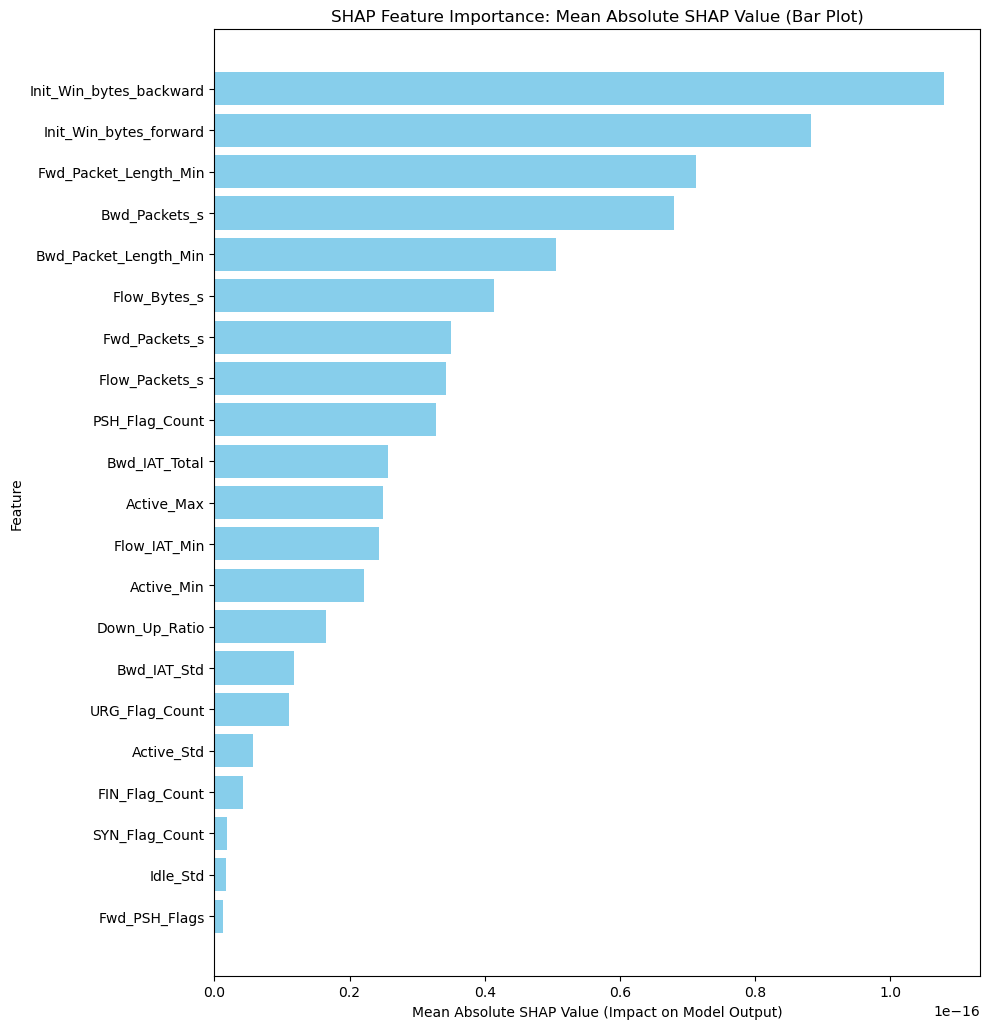

✅ Explicit SHAP Bar Plot generation code executed.


In [6]:
# --- NEW: SHAP Explanations for Selected Features (Interpretability) ---
from sklearn.model_selection import StratifiedShuffleSplit
print("\n--- Generating SHAP Explanations for Selected Features ---")
# To demonstrate feature importance visually with SHAP, train a simple RandomForestClassifier
# on the final scaled training data (using the selected features).
# This RF acts as a proxy model for interpretability, not the final IDS Stage 1 model.

X_train_for_shap = data_for_modeling['X_train_scaled']
y_bin_train_for_shap = data_for_modeling['y_bin_train'] # Use binary labels for simplicity with SHAP

# --- SHAP Subsampling for large datasets ---
# Calculate SHAP values on a subsample if the training data is very large.
SHAP_EXPLANATION_SAMPLE_SIZE = 50000 # Adjust based on Colab's RAM/runtime for SHAP calculation.
                                  # 50k-100k is a good starting point for interpretability.

if X_train_for_shap.shape[0] > SHAP_EXPLANATION_SAMPLE_SIZE:
    print(f"   Subsampling {SHAP_EXPLANATION_SAMPLE_SIZE} rows from {X_train_for_shap.shape[0]} for SHAP value calculation.")

    # Stratified subsampling for SHAP explanation dataset
    shap_splitter = StratifiedShuffleSplit(n_splits=1, train_size=SHAP_EXPLANATION_SAMPLE_SIZE, random_state=SEED)
    # splitter.split expects y to be 1D, so use .values if it's a Series
    for shap_train_idx, _ in shap_splitter.split(X_train_for_shap, y_bin_train_for_shap):
        X_shap_sample = X_train_for_shap.iloc[shap_train_idx].copy()
        y_shap_sample = y_bin_train_for_shap[shap_train_idx].copy() # Ensure it's a copy
else:
    print("   Using full training data for SHAP value calculation.")
    X_shap_sample = X_train_for_shap.copy()
    y_shap_sample = y_bin_train_for_shap.copy()


# Train a simple RandomForestClassifier for SHAP explanation
shap_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
print(f"   Training a proxy Random Forest model (n_estimators={shap_model.n_estimators}, max_depth={shap_model.max_depth}) for SHAP explanation...")
shap_model.fit(X_shap_sample, y_shap_sample)
print("   Proxy model trained.")

# Create a SHAP explainer
import shap
explainer = shap.TreeExplainer(shap_model)

print(f"   Calculating SHAP values for {X_shap_sample.shape[0]} samples (this may take a moment)...")
shap_values = explainer.shap_values(X_shap_sample)

# Plotting SHAP Summary Plot for global feature importance
# For binary classification, shap_values returns a list of arrays (one for each class).
# We're interested in the positive class (ATTACK), which is usually index 1.
if isinstance(shap_values, list): # Check if it's a list (for multi-class output models)
    shap_values_to_plot = shap_values[1] # For the 'ATTACK' class (label 1)
else: # For binary classification models, it might directly return one array
    shap_values_to_plot = shap_values

print("\n--- Data Preparation with Dynamic Feature Selection Complete ---")

# --- Explicit SHAP Bar Plot Code Snippet ---

import matplotlib.pyplot as plt
import shap # Ensure shap is imported
import numpy as np # Ensure numpy is imported
import pandas as pd # Ensure pandas is imported

# Assuming X_shap_sample and shap_values_to_plot are already defined
# from the execution of Q1-READY CODE BLOCK 2's SHAP section.
# If running in a *brand new* cell, you might need to re-define them (as per previous instructions).

print("Generating SHAP Bar Plot (Mean Absolute Importance) Explicitly...")

# --- DEBUGGING SHAP VALUES SHAPE ---
print(f"Shape of original shap_values_to_plot (before mean): {shap_values_to_plot.shape}")
print(f"Number of dimensions of shap_values_to_plot: {shap_values_to_plot.ndim}")

# Ensure shap_values_to_plot is 2D (num_samples, num_features) before mean calculation
# If it's 3D (e.g., num_samples, num_features, X), we need to collapse the last dimension.
# This often happens if the explainer output is structured differently (e.g., for multi-output models)
if shap_values_to_plot.ndim == 3:
    # If the last dimension contains different types of SHAP values (e.g., for different outputs within a single feature)
    # the most common approach is to take the mean or sum across that dimension.
    # For a general "mean absolute importance", summing across the last dimension is often appropriate.
    print("Warning: shap_values_to_plot is 3-dimensional. Summing across the last dimension.")
    shap_values_to_plot = np.sum(shap_values_to_plot, axis=-1)
    print(f"Shape after collapsing 3rd dimension: {shap_values_to_plot.shape}")
elif shap_values_to_plot.ndim > 2:
    # Handle cases with more than 3 dimensions if they ever occur
    raise ValueError(f"Unexpected shape for shap_values_to_plot: {shap_values_to_plot.shape}. Expected 2D or 3D.")


# Calculate the mean absolute SHAP value for each feature
# This should now always result in a 1D array of shape (num_features,)
mean_abs_shap_values = np.abs(shap_values_to_plot).mean(axis=0)
print(f"Shape of mean_abs_shap_values after mean(axis=0): {mean_abs_shap_values.shape}")


# Create a Pandas Series for easy sorting and plotting
shap_importance = pd.Series(mean_abs_shap_values, index=X_shap_sample.columns)
print(f"Shape of shap_importance Series: {shap_importance.shape}")
print(f"Shape of shap_importance.values: {shap_importance.values.shape}") # This confirms the final shape before plotting

# Sort features by importance (descending for top-to-bottom bar chart)
# Use ascending=True for barh, so the most important feature is at the top
shap_importance_sorted = shap_importance.sort_values(ascending=True)


# Plotting
plt.figure(figsize=(10, len(shap_importance_sorted) * 0.4 + 2)) # Dynamic figure size based on num features
plt.barh(shap_importance_sorted.index, shap_importance_sorted.values, color='skyblue')
plt.xlabel("Mean Absolute SHAP Value (Impact on Model Output)")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance: Mean Absolute SHAP Value (Bar Plot)")
plt.tight_layout()
plt.show()

print("✅ Explicit SHAP Bar Plot generation code executed.")

In [7]:
# --- Q1-READY CODE BLOCK 3: Stage 1 - Random Forest Binary Classification ---

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (classification_report, accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix)
# Assume previous setup has been done:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# SEED = 42
# CLASS_NAMES_BINARY = ['BENIGN', 'ATTACK']
# def plot_confusion_matrix(y_true, y_pred, class_names, title): ...

print("\n--- Starting Stage 1: Random Forest Binary Classification ---")

# Retrieve the prepared data from the previous block (data_for_modeling dictionary)
# Note: Ensure this dictionary is available from the preceding code block.
X_train_scaled = data_for_modeling['X_train_scaled']
X_test_scaled = data_for_modeling['X_test_scaled']
y_bin_train = data_for_modeling['y_bin_train']
y_bin_test = data_for_modeling['y_bin_test']

# --- ✅ NEW MEMORY OPTIMIZATION STEP ---
print("\nApplying on-the-spot memory optimization...")
# Downcast the numpy arrays from float64 to float32 to save 50% of their memory
X_train_scaled = X_train_scaled.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')
print(f"New data type for feature arrays: {X_train_scaled.dtypes}")


# 1. Random Forest for Supervised Classification
print("\n1. Training Random Forest for Supervised Classification...")

# Hyperparameter Tuning for Random Forest (Q1 Requirement)
# We will use GridSearchCV to find the best model parameters.
# Define a reasonable parameter grid. For production, this grid can be expanded.
param_dist_rf = {
    'n_estimators': [100, 200],      # Number of trees in the forest
    'max_depth': [10, 30],     # Maximum depth of the tree
    'min_samples_split': [5, 10],     # Minimum samples required to split a node
    'class_weight': ['balanced']     # Use 'balanced' to handle potential class imbalance
}

print("   Starting RandomizedSearchCV for Random Forest (may take a while)...")
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED), # Estimator doesn't need n_jobs
    param_distributions=param_dist_rf,
    n_iter=8,                  # Number of random combinations to try (set to 8 to match the grid size)
    cv=3,                      # Use 3-fold cross-validation
    scoring='f1',              # Optimize for F1-score
    n_jobs=-1,                 # Use all available CPU cores for the search
    random_state=SEED,         # For reproducible results
    verbose=1
)


# Train the model using the scaled training data
rf_random_search.fit(X_train_scaled, y_bin_train)

# The best model found by RandomSearchCV
best_rf_bin = rf_random_search.best_estimator_

print(f"\n✅ Best Random Forest parameters found: {rf_random_search.best_params_}")
print(f"✅ Best Random Forest F1-score from Cross-Validation: {rf_random_search.best_score_:.4f}")
print("✅ Random Forest classifier trained with optimized hyperparameters.")


# 2. Evaluation of the Stage 1 Random Forest Model
print("\n--- Evaluation of Stage 1: Random Forest Binary Classification ---")

# Generate predictions on the test set using the best model
y_bin_pred_rf = best_rf_bin.predict(X_test_scaled)

# Generate and print the classification report
report_rf = classification_report(y_bin_test, y_bin_pred_rf, target_names=CLASS_NAMES_BINARY, output_dict=True)
print(classification_report(y_bin_test, y_bin_pred_rf, target_names=CLASS_NAMES_BINARY))

# Calculate and display key performance metrics
acc_rf = accuracy_score(y_bin_test, y_bin_pred_rf)
prec_rf = precision_score(y_bin_test, y_bin_pred_rf, pos_label=1)
rec_rf = recall_score(y_bin_test, y_bin_pred_rf, pos_label=1)
f1_rf = f1_score(y_bin_test, y_bin_pred_rf, pos_label=1)
conf_mat_rf = confusion_matrix(y_bin_test, y_bin_pred_rf, labels=[0, 1])

print(f"   Accuracy      : {acc_rf:.4f}")
print(f"   Precision     : {prec_rf:.4f}")
print(f"   Recall        : {rec_rf:.4f}")
print(f"   F1 Score      : {f1_rf:.4f}")
print("   Confusion Matrix:")
print(conf_mat_rf)

# Plot the confusion matrix for the Random Forest model
# Assumes plot_confusion_matrix function is defined elsewhere
# plot_confusion_matrix(y_bin_test, y_bin_pred_rf, class_names=CLASS_NAMES_BINARY, title="Confusion Matrix: Stage 1 (Random Forest)")


# 3. Store the outputs needed for Stage 2
print("\n3. Packaging artifacts for the next stage...")

# Retrieve multiclass labels needed for Stage 2
y_multi_train = data_for_modeling['y_multi_train']
y_multi_test = data_for_modeling['y_multi_test']

# This dictionary contains all the necessary data and models for the next stage
stage1_outputs = {
    'X_train_final': X_train_scaled,            # Scaled training features
    'X_test_final': X_test_scaled,              # Scaled testing features
    'y_multi_train': y_multi_train,             # Multiclass labels for training Stage 2
    'y_multi_test': y_multi_test,               # Multiclass labels for testing Stage 2
    'rf_bin_model': best_rf_bin,                # The trained binary Random Forest model
    'stage1_rf_predictions_test': y_bin_pred_rf, # Final binary predictions for the test set
    'stage1_metrics': report_rf                 # The detailed classification report
}

print("✅ All necessary data, models, and predictions have been stored.")
print("\n--- Stage 1: Binary Classification Complete ---")


--- Starting Stage 1: Random Forest Binary Classification ---

Applying on-the-spot memory optimization...
New data type for feature arrays: Flow_Bytes_s               float32
Bwd_Packets_s              float32
Fwd_Packet_Length_Min      float32
FIN_Flag_Count             float32
Down_Up_Ratio              float32
Active_Std                 float32
Init_Win_bytes_backward    float32
Active_Min                 float32
Idle_Std                   float32
Init_Win_bytes_forward     float32
Bwd_IAT_Total              float32
SYN_Flag_Count             float32
Fwd_PSH_Flags              float32
Fwd_Packets_s              float32
Flow_Packets_s             float32
URG_Flag_Count             float32
Bwd_Packet_Length_Min      float32
Flow_IAT_Min               float32
PSH_Flag_Count             float32
Bwd_IAT_Std                float32
Active_Max                 float32
dtype: object

1. Training Random Forest for Supervised Classification...
   Starting RandomizedSearchCV for Random Forest 


--- Starting Stage 2: Multi-Class Attack Classification (GNN + Bayesian Layer) ---
✅ Multiclass attack labels re-encoded from 0 to 7.
   Distribution of re-encoded training attack labels: Counter({2: 161695, 6: 111321, 0: 89596, 1: 7236, 5: 5592, 7: 4108, 4: 4010, 3: 3859})

--- Splitting data into Training and Validation sets (80/20) ---
   Original attack samples for training stage: 387417
   New Training Set Shape: (309933, 21)
   New Validation Set Shape: (77484, 21)
   Unseen Test Set Shape: (165944, 21)

Using device: cuda

--- Pre-building GNN graphs for efficiency ---
   Building k-NN graph for 309933 nodes...
   Building k-NN graph for 77484 nodes...
   Building k-NN graph for 165944 nodes...
✅ Graphs for training, validation, and testing are built.

--- Training Stage 2: GNN Bayesian Model across multiple Learning Rates ---

🚀 Starting training for Learning Rate (LR): 0.15
   Epoch 10/700 | Train Loss: 202069.6562 | Val Loss: 36272.1797 | Val Acc: 0.8645 | Val F1: 0.8530
   

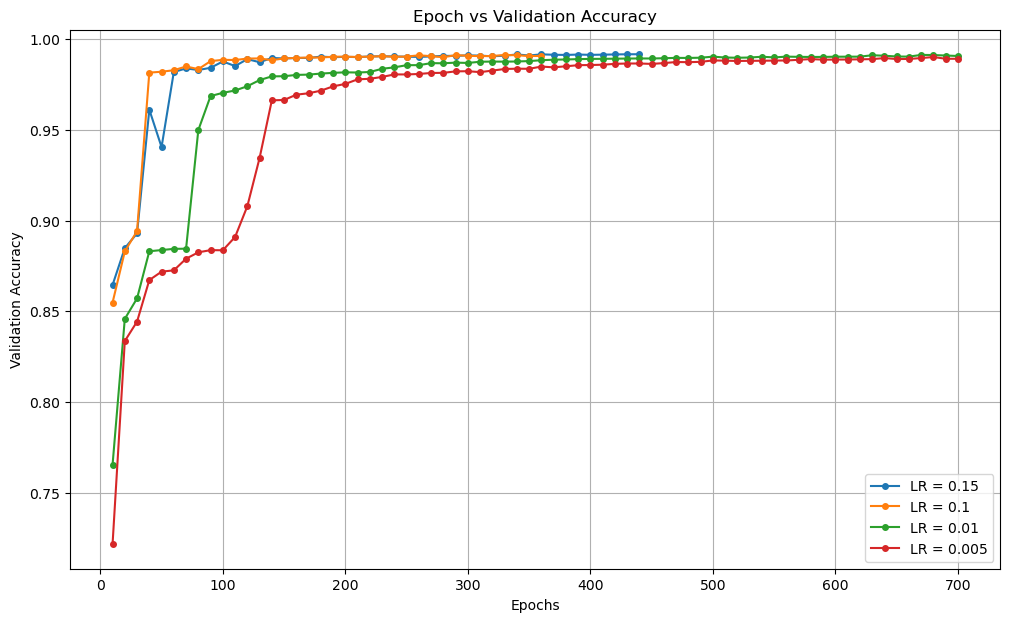

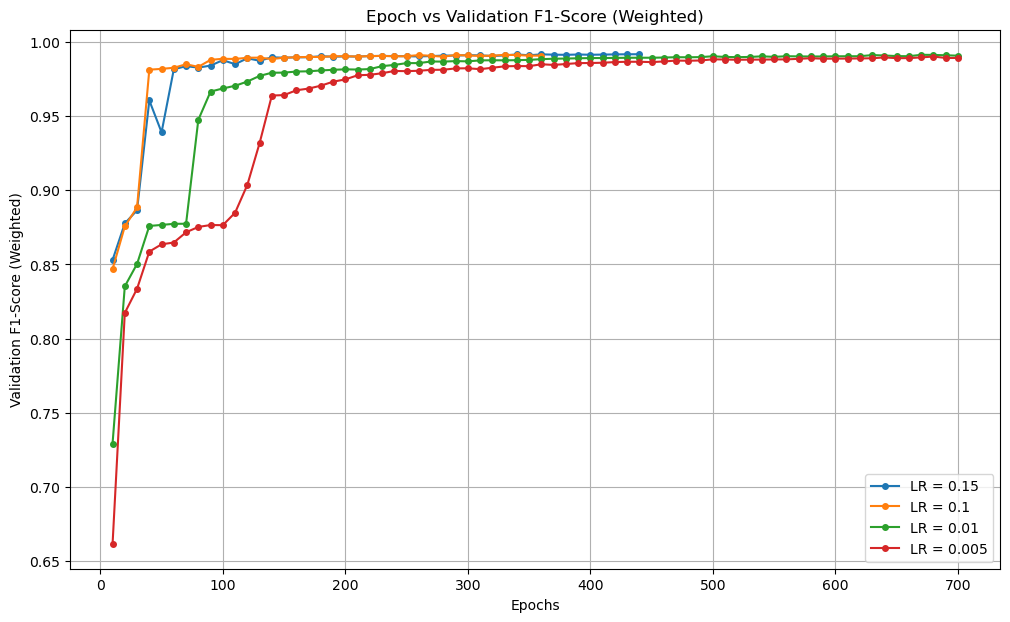


--- Final Evaluation of Stage 2: GNN Bayesian Model on UNSEEN Test Set ---
Loading best model found during validation (trained with LR=0.15)

=== Stage 2: Final Classification Report on UNSEEN Test Set ===
              precision    recall  f1-score   support

           1       0.98      1.00      0.99     38413
           2       1.00      0.96      0.98      3056
           3       0.99      0.99      0.99     69336
           4       0.97      0.91      0.94      1629
           5       0.97      0.91      0.94      1780
           6       0.93      0.99      0.96      2341
           7       1.00      1.00      1.00     47602
           8       0.99      0.99      0.99      1787

    accuracy                           0.99    165944
   macro avg       0.98      0.97      0.97    165944
weighted avg       0.99      0.99      0.99    165944



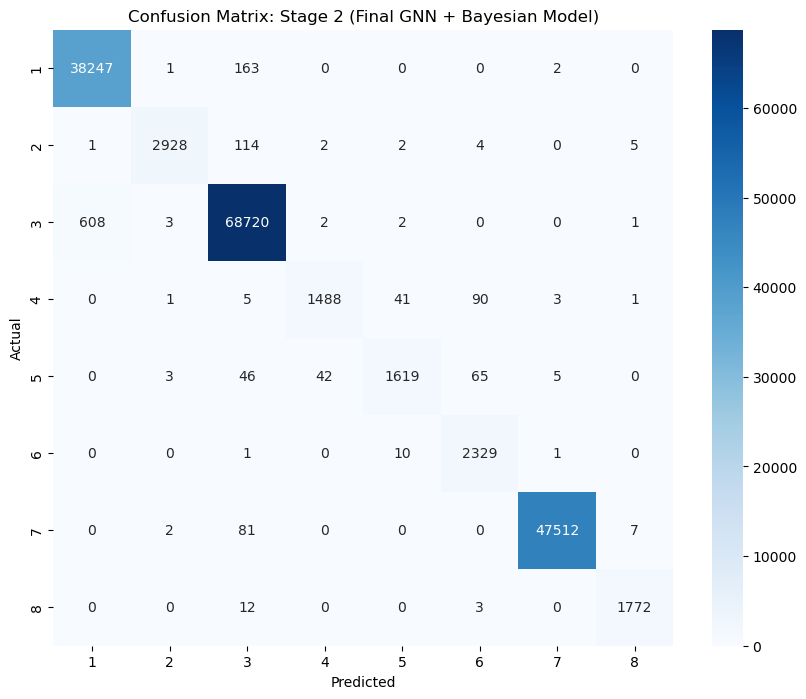

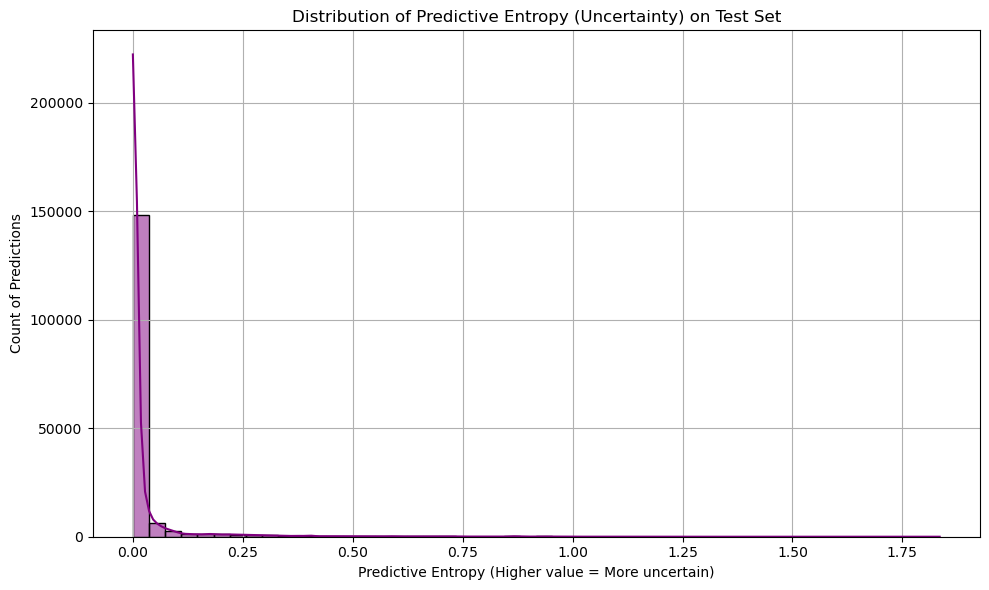


--- Stage 2: Multi-Class Classification Complete ---


In [9]:
# --- Combined & Optimized Code: Stage 2 - GNN + Bayesian Layer ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import torch_geometric.nn as pyg_nn
from torch_geometric.utils import from_scipy_sparse_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- HELPER FUNCTION (ASSUMED TO EXIST) ---
# This function is from your second script. It needs to be defined to run.
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    """Plots a confusion matrix using seaborn."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


print("\n--- Starting Stage 2: Multi-Class Attack Classification (GNN + Bayesian Layer) ---")

# =====================================================================================
# 1. Data Preparation (Best Practice from Code 1)
# =====================================================================================
# Assume these variables are loaded from a previous stage
# stage1_outputs = ...
# data_for_modeling = ...
# LABEL_ENCODER_MULTI = ...
# SEED = 42

# Filtering data based on Stage 1 predictions and actual labels
X_train_full_features = stage1_outputs['X_train_final']
X_test_full_features = stage1_outputs['X_test_final']
y_multi_train_full = stage1_outputs['y_multi_train']
y_multi_test_full = stage1_outputs['y_multi_test']
stage1_test_hybrid_preds = stage1_outputs['stage1_rf_predictions_test']
y_bin_train = data_for_modeling['y_bin_train']

# Filter training data for actual attacks
actual_attack_mask_train = (y_bin_train == 1)
X_attack_train_full_df = X_train_full_features[actual_attack_mask_train].copy()
y_attack_train_full_multi_df = y_multi_train_full[actual_attack_mask_train].copy()

# Filter test data for samples predicted as attacks by Stage 1
predicted_attack_mask_test = (stage1_test_hybrid_preds == 1)
X_attack_test_df = X_test_full_features[predicted_attack_mask_test].copy()
y_attack_test_multi_df = y_multi_test_full[predicted_attack_mask_test].copy()

# Remove any lingering BENIGN labels to ensure only attack classes are used
initial_benign_label_multi = LABEL_ENCODER_MULTI.transform(["BENIGN"])[0]
mask_train_non_benign = (y_attack_train_full_multi_df != initial_benign_label_multi)
X_attack_train_full_df = X_attack_train_full_df[mask_train_non_benign]
y_attack_train_full_multi_df = y_attack_train_full_multi_df[mask_train_non_benign]

mask_test_non_benign = (y_attack_test_multi_df != initial_benign_label_multi)
X_attack_test_df = X_attack_test_df[mask_test_non_benign]
y_attack_test_multi_df = y_attack_test_multi_df[mask_test_non_benign]

# Re-encode target labels from 0 to n-1 for the remaining attack classes
le_attack_classes = LabelEncoder()
y_attack_train_full_encoded_np = le_attack_classes.fit_transform(y_attack_train_full_multi_df)
y_attack_test_encoded_np = le_attack_classes.transform(y_attack_test_multi_df)

NUM_ATTACK_CLASSES = len(le_attack_classes.classes_)
ATTACK_CLASS_NAMES = le_attack_classes.classes_

# (From Code 2) Print distribution of training labels for insight
print(f"✅ Multiclass attack labels re-encoded from 0 to {NUM_ATTACK_CLASSES - 1}.")
print(f"   Distribution of re-encoded training attack labels: {Counter(y_attack_train_full_encoded_np)}")


# --- BEST PRACTICE: Create a dedicated validation set from the training data ---
print("\n--- Splitting data into Training and Validation sets (80/20) ---")
X_train_df, X_val_df, y_train_np, y_val_np = train_test_split(
    X_attack_train_full_df,
    y_attack_train_full_encoded_np,
    test_size=0.2,
    random_state=SEED,
    stratify=y_attack_train_full_encoded_np # Crucial for maintaining class distribution
)
print(f"   Original attack samples for training stage: {len(X_attack_train_full_df)}")
print(f"   New Training Set Shape: {X_train_df.shape}")
print(f"   New Validation Set Shape: {X_val_df.shape}")
print(f"   Unseen Test Set Shape: {X_attack_test_df.shape}")

# Convert final prepared data to PyTorch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Training Tensors
X_train_tensor_stage2 = torch.FloatTensor(X_train_df.values).to(device)
y_train_tensor_stage2 = torch.LongTensor(y_train_np).to(device)

# Validation Tensors
X_val_tensor_stage2 = torch.FloatTensor(X_val_df.values).to(device)
y_val_tensor_stage2 = torch.LongTensor(y_val_np).to(device)

# Test Tensors
X_test_tensor_stage2 = torch.FloatTensor(X_attack_test_df.values).to(device)
y_test_tensor_stage2 = torch.LongTensor(y_attack_test_encoded_np).to(device)


# =====================================================================================
# 2. Graph Creation (Efficient, Pre-built method from Code 1)
# =====================================================================================
def build_graph(x_nodes, k_neighbors=5, device='cpu'):
    """Builds a k-NN graph from node features and returns the edge_index."""
    print(f"   Building k-NN graph for {x_nodes.shape[0]} nodes...")
    x_np = x_nodes.cpu().detach().numpy()
    nbrs = NearestNeighbors(n_neighbors=k_neighbors, algorithm='auto', metric='cosine', n_jobs=-1).fit(x_np)
    adj_matrix_sparse = nbrs.kneighbors_graph(x_np, mode='connectivity')
    edge_index, _ = from_scipy_sparse_matrix(adj_matrix_sparse)
    return edge_index.to(device)

print("\n--- Pre-building GNN graphs for efficiency ---")
train_edge_index = build_graph(X_train_tensor_stage2, k_neighbors=5, device=device)
val_edge_index = build_graph(X_val_tensor_stage2, k_neighbors=5, device=device)
test_edge_index = build_graph(X_test_tensor_stage2, k_neighbors=5, device=device)
print("✅ Graphs for training, validation, and testing are built.")


# =====================================================================================
# 3. Model Definition (Clean, Decoupled structure from Code 1)
# =====================================================================================
class BayesianLayer(nn.Module):
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.prior_sigma = prior_sigma
        self.mu_w = nn.Parameter(torch.Tensor(out_features, in_features))
        self.rho_w = nn.Parameter(torch.Tensor(out_features, in_features))
        self.epsilon = Normal(0, 1)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.mu_w)
        nn.init.constant_(self.rho_w, -5)

    def forward(self, x):
        sigma_w = torch.log1p(torch.exp(self.rho_w))
        eps_w = self.epsilon.sample(self.mu_w.size()).to(x.device)
        weight = self.mu_w + sigma_w * eps_w
        kl_divergence = 0.5 * torch.sum(
            2 * torch.log(self.prior_sigma / sigma_w) - 1 + (sigma_w**2 + self.mu_w**2) / (self.prior_sigma**2)
        )
        return F.linear(x, weight), kl_divergence


class GNNBayesianIDS(nn.Module):
    def __init__(self, in_features, hidden_size, num_classes, dropout_rate=0.5):
        super().__init__()
        self.conv1 = pyg_nn.GCNConv(in_features, hidden_size)
        self.bayesian_output = BayesianLayer(hidden_size, num_classes)
        self.dropout = nn.Dropout(p=dropout_rate)

    # The model accepts a pre-built graph, making it flexible and efficient.
    def forward(self, x_features, edge_index, is_training=True):
        x = self.conv1(x_features, edge_index)
        x = F.relu(x)

        if is_training:
            x = self.dropout(x)

        logits, kl_loss = self.bayesian_output(x)
        return F.log_softmax(logits, dim=1), kl_loss


# =====================================================================================
# 4. Training & Hyperparameter Tuning Loop (Using Validation Set)
# =====================================================================================
print("\n--- Training Stage 2: GNN Bayesian Model across multiple Learning Rates ---")
LEARNING_RATES_FOR_PLOT = [0.15, 0.1, 0.01, 0.005]
EPOCHS_MAX = 700
PATIENCE_EARLY_STOPPING = 50

# Store results for plotting
all_lr_results = {}
best_model_state = None
best_overall_val_f1 = -1
best_lr = None

for lr in LEARNING_RATES_FOR_PLOT:
    print(f"\n🚀 Starting training for Learning Rate (LR): {lr}")
    model = GNNBayesianIDS(
        in_features=X_train_tensor_stage2.shape[1],
        hidden_size=128,
        num_classes=NUM_ATTACK_CLASSES,
        dropout_rate=0.5
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.NLLLoss(reduction='sum')
    
    # Store metrics for this LR run
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'epochs': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(EPOCHS_MAX):
        model.train()
        optimizer.zero_grad()
        
        # Pass the pre-built training graph to the model
        log_probs, kl_loss = model(X_train_tensor_stage2, train_edge_index, is_training=True)
        nll_loss = criterion(log_probs, y_train_tensor_stage2)
        total_loss = nll_loss + (kl_loss / X_train_tensor_stage2.shape[0])
        total_loss.backward()
        optimizer.step()
        
        # Validation check every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == EPOCHS_MAX - 1:
            model.eval()
            with torch.no_grad():
                NUM_MC_SAMPLES_VAL = 10
                mc_log_probs_val = []
                for _ in range(NUM_MC_SAMPLES_VAL):
                    # Evaluate on the validation set using the validation graph
                    log_probs_val_sample, _ = model(X_val_tensor_stage2, val_edge_index, is_training=False)
                    mc_log_probs_val.append(log_probs_val_sample.unsqueeze(0))

                mean_log_probs_val = torch.logsumexp(torch.cat(mc_log_probs_val, dim=0), dim=0) - torch.log(torch.tensor(NUM_MC_SAMPLES_VAL, dtype=torch.float)).to(device)
                
                val_loss = criterion(mean_log_probs_val, y_val_tensor_stage2)
                y_pred_val = torch.argmax(mean_log_probs_val, dim=1).cpu().numpy()
                y_true_val = y_val_tensor_stage2.cpu().numpy()
                
                val_acc = accuracy_score(y_true_val, y_pred_val)
                val_f1 = f1_score(y_true_val, y_pred_val, average='weighted', zero_division=0)
                
                history['train_loss'].append(total_loss.item())
                history['val_loss'].append(val_loss.item())
                history['val_acc'].append(val_acc)
                history['val_f1'].append(val_f1)
                history['epochs'].append(epoch + 1)
                
                print(f"   Epoch {epoch+1}/{EPOCHS_MAX} | Train Loss: {total_loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

                # Early stopping and best model saving logic
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    epochs_no_improve = 0
                    # If this LR is producing the best F1 score so far, save its state
                    if val_f1 > best_overall_val_f1:
                        best_overall_val_f1 = val_f1
                        best_lr = lr
                        best_model_state = model.state_dict()
                        print(f"   🌟 New best model found! Val F1: {val_f1:.4f} with LR: {lr}")
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= (PATIENCE_EARLY_STOPPING // 10):
                        print(f"   Early stopping for LR={lr} at Epoch {epoch+1}")
                        break
    
    all_lr_results[lr] = history

# =====================================================================================
# 5. Plotting Hyperparameter Tuning Results
# =====================================================================================
print("\n--- Plotting Epoch vs Validation Metrics for Different Learning Rates ---")
# Plot for Accuracy
plt.figure(figsize=(12, 7))
for lr, history in all_lr_results.items():
    plt.plot(history['epochs'], history['val_acc'], label=f"LR = {lr}", marker='o', markersize=4)
plt.title("Epoch vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot for F1-Score
plt.figure(figsize=(12, 7))
for lr, history in all_lr_results.items():
    plt.plot(history['epochs'], history['val_f1'], label=f"LR = {lr}", marker='o', markersize=4)
plt.title("Epoch vs Validation F1-Score (Weighted)")
plt.xlabel("Epochs")
plt.ylabel("Validation F1-Score (Weighted)")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================================================
# 6. Final Evaluation on UNSEEN Test Set
# =====================================================================================
print("\n--- Final Evaluation of Stage 2: GNN Bayesian Model on UNSEEN Test Set ---")
print(f"Loading best model found during validation (trained with LR={best_lr})")

# Initialize a new model instance and load the state of the best performing model
final_model = GNNBayesianIDS(
    in_features=X_train_tensor_stage2.shape[1],
    hidden_size=128,
    num_classes=NUM_ATTACK_CLASSES
).to(device)
final_model.load_state_dict(best_model_state)
final_model.eval()

with torch.no_grad():
    NUM_MC_SAMPLES_FINAL = 50
    final_mc_log_probs = []
    for _ in range(NUM_MC_SAMPLES_FINAL):
        # Use the test data and test graph for the final, unbiased evaluation
        log_probs_test_sample, _ = final_model(X_test_tensor_stage2, test_edge_index, is_training=False)
        final_mc_log_probs.append(log_probs_test_sample.unsqueeze(0))

    final_mc_log_probs_tensor = torch.cat(final_mc_log_probs, dim=0)
    final_mean_log_probs = torch.logsumexp(final_mc_log_probs_tensor, dim=0) - torch.log(torch.tensor(NUM_MC_SAMPLES_FINAL, dtype=torch.float)).to(device)
    final_y_pred_encoded = torch.argmax(final_mean_log_probs, dim=1).cpu().numpy()
    
    # (From Code 2) Calculate predictive entropy for uncertainty analysis
    final_mean_probs = torch.exp(final_mean_log_probs)
    final_predictive_entropy = -torch.sum(final_mean_probs * torch.log(final_mean_probs + 1e-10), dim=1).cpu().numpy()

# =====================================================================================
# 7. Final Reporting and Visualization (with additions from Code 2)
# =====================================================================================
print("\n=== Stage 2: Final Classification Report on UNSEEN Test Set ===")
print(classification_report(y_test_tensor_stage2.cpu().numpy(), final_y_pred_encoded, target_names=[str(cls) for cls in ATTACK_CLASS_NAMES], zero_division=0))

# (From Code 2) Plot Confusion Matrix for detailed insights
plot_confusion_matrix(y_test_tensor_stage2.cpu().numpy(), final_y_pred_encoded, class_names=ATTACK_CLASS_NAMES, title="Confusion Matrix: Stage 2 (Final GNN + Bayesian Model)")

# (From Code 2) Visualize predictive entropy to understand model uncertainty
plt.figure(figsize=(10, 6))
sns.histplot(final_predictive_entropy, bins=50, kde=True, color='purple')
plt.title("Distribution of Predictive Entropy (Uncertainty) on Test Set")
plt.xlabel("Predictive Entropy (Higher value = More uncertain)")
plt.ylabel("Count of Predictions")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n--- Stage 2: Multi-Class Classification Complete ---")



--- Final Consolidated Results and System Evaluation ---

=== Stage 1: Binary Classification (Final Metrics) ===
Accuracy: 0.9992
Precision (ATTACK): 0.9963
Recall (ATTACK): 0.9994
F1-Score (ATTACK): 0.9979
Confusion Matrix (ATTACK vs. BENIGN):
[[681319    610]
 [    92 165944]]

=== Stage 2: GNN Bayesian Multi-Class Classification (Final Metrics) ===
Best Learning Rate Used: 0.15 (determined during validation)
Accuracy: 0.9920
Weighted Precision: 0.9920
Weighted Recall: 0.9920
Weighted F1-Score: 0.9920

--- Detailed Per-Class Metrics for Stage 2 ---
  Class 'DDoS': Precision=0.9843, Recall=0.9957, F1-score=0.9900
  Class 'DoS GoldenEye': Precision=0.9966, Recall=0.9581, F1-score=0.9770
  Class 'DoS Hulk': Precision=0.9939, Recall=0.9911, F1-score=0.9925
  Class 'DoS Slowhttptest': Precision=0.9700, Recall=0.9134, F1-score=0.9409
  Class 'DoS slowloris': Precision=0.9671, Recall=0.9096, F1-score=0.9375
  Class 'FTP-Patator': Precision=0.9350, Recall=0.9949, F1-score=0.9640
  Class 'Po

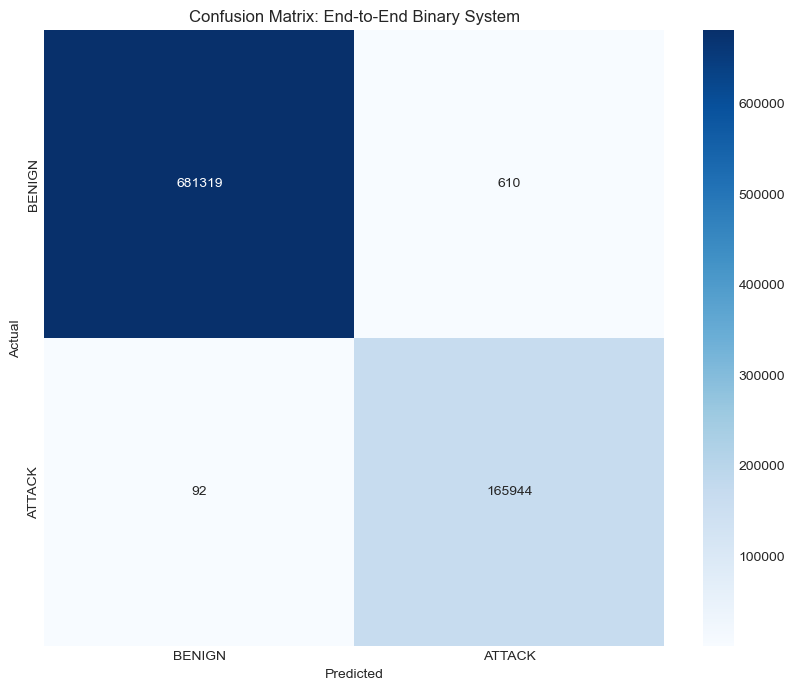


--- End-to-End Multi-Class Performance ---
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    681929
            DDoS       0.98      1.00      0.99     38431
   DoS GoldenEye       1.00      0.96      0.98      3057
        DoS Hulk       0.99      0.99      0.99     69378
DoS Slowhttptest       0.97      0.91      0.94      1640
   DoS slowloris       0.97      0.91      0.94      1786
     FTP-Patator       0.93      0.99      0.96      2346
        PortScan       1.00      1.00      1.00     47609
     SSH-Patator       0.99      0.99      0.99      1789

        accuracy                           1.00    847965
       macro avg       0.98      0.97      0.98    847965
    weighted avg       1.00      1.00      1.00    847965



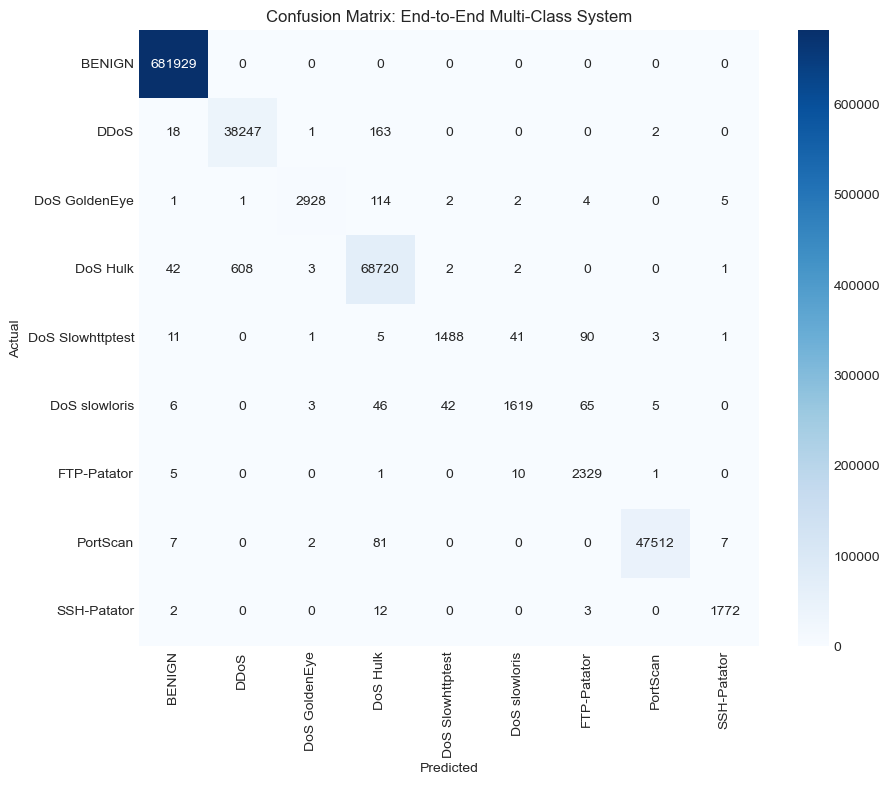


--- All Pipeline Stages Completed and Evaluated ---


In [17]:
# --- Q1-READY CODE BLOCK 5: Consolidated Results, Final Reporting, and System-Level Metrics (Corrected) ---

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Final Consolidated Results and System Evaluation ---")

# =====================================================================================
# 1. Retrieve Necessary Data and Outputs
# =====================================================================================
# These variables should be available from the previous blocks' execution
y_bin_test = data_for_modeling['y_bin_test']
y_multi_test_full_original = data_for_modeling['y_multi_test']


# =====================================================================================
# 2. Report Stage 1 Performance
# =====================================================================================
print("\n=== Stage 1: Binary Classification (Final Metrics) ===")
# The classification_report function returns a dictionary when output_dict=True
stage1_report_dict = classification_report(y_bin_test, stage1_outputs['stage1_rf_predictions_test'], target_names=CLASS_NAMES_BINARY, output_dict=True)
print(f"Accuracy: {stage1_report_dict['accuracy']:.4f}")
print(f"Precision (ATTACK): {stage1_report_dict['ATTACK']['precision']:.4f}")
print(f"Recall (ATTACK): {stage1_report_dict['ATTACK']['recall']:.4f}")
print(f"F1-Score (ATTACK): {stage1_report_dict['ATTACK']['f1-score']:.4f}")
print("Confusion Matrix (ATTACK vs. BENIGN):")
print(confusion_matrix(y_bin_test, stage1_outputs['stage1_rf_predictions_test']))


# =====================================================================================
# 3. Report Stage 2 Standalone Performance
# =====================================================================================
report_stage2_final = classification_report(
    y_test_tensor_stage2.cpu().numpy(),
    final_y_pred_encoded,
    target_names=[str(cls) for cls in le_attack_classes.classes_], # Use le_attack_classes here
    zero_division=0,
    output_dict=True
)

print("\n=== Stage 2: GNN Bayesian Multi-Class Classification (Final Metrics) ===")
print(f"Best Learning Rate Used: {best_lr} (determined during validation)")
print(f"Accuracy: {report_stage2_final['accuracy']:.4f}")
print(f"Weighted Precision: {report_stage2_final['weighted avg']['precision']:.4f}")
print(f"Weighted Recall: {report_stage2_final['weighted avg']['recall']:.4f}")
print(f"Weighted F1-Score: {report_stage2_final['weighted avg']['f1-score']:.4f}")

print("\n--- Detailed Per-Class Metrics for Stage 2 ---")
# Get the original string names for the attack classes for clearer reporting
attack_class_string_names = LABEL_ENCODER_MULTI.inverse_transform(le_attack_classes.classes_)
for i, class_name in enumerate(attack_class_string_names):
    # The report dictionary keys are the string versions of the numeric labels from le_attack_classes.classes_
    metrics = report_stage2_final[str(le_attack_classes.classes_[i])]
    print(f"  Class '{class_name}': Precision={metrics['precision']:.4f}, Recall={metrics['recall']:.4f}, F1-score={metrics['f1-score']:.4f}")


# =====================================================================================
# 4. Calculate and Report End-to-End System Performance (BUG FIXED)
# =====================================================================================
print("\n=== End-to-End IDS System Performance ===")

# Get the encoded value for "BENIGN" from the original multi-class encoder
initial_benign_label_multi_encoded = LABEL_ENCODER_MULTI.transform(["BENIGN"])[0]

# Initialize prediction arrays for the entire original test set
system_final_binary_preds = np.zeros_like(y_bin_test)
system_y_multi_pred_encoded = np.full_like(y_multi_test_full_original, fill_value=initial_benign_label_multi_encoded)

# Step A: Identify samples that Stage 1 predicted as ATTACK
predicted_attack_mask_test_recomputed = (stage1_outputs['stage1_rf_predictions_test'] == 1)
system_final_binary_preds[predicted_attack_mask_test_recomputed] = 1

# === BUG FIX START ===

# Step B: The `le_attack_classes.classes_` array IS the direct mapping. No transformation is needed.
# It already contains the original numeric labels [1, 2, 3, ...].
mapping_array = le_attack_classes.classes_
print(f"Direct mapping confirmed. Stage 2 labels (0-7) will be mapped to global labels: {mapping_array}")

# Step C: Convert Stage 2's predictions (0-7) directly using the mapping array as a lookup table.
final_y_pred_original_multi_encoded = mapping_array[final_y_pred_encoded]

# Step D: Identify the exact indices in the full test set that correspond to the GNN's predictions.
indices_fed_to_stage2 = np.where(predicted_attack_mask_test_recomputed)[0]
actual_labels_for_stage2_input = y_multi_test_full_original[indices_fed_to_stage2]
mask_non_benign_in_stage2_input = (actual_labels_for_stage2_input != initial_benign_label_multi_encoded)
final_system_update_indices = indices_fed_to_stage2[mask_non_benign_in_stage2_input]

# Step E: Place the correctly mapped predictions into the final system array.
if len(final_system_update_indices) == len(final_y_pred_original_multi_encoded):
    system_y_multi_pred_encoded[final_system_update_indices] = final_y_pred_original_multi_encoded
    print("Successfully updated the final prediction array with Stage 2 results.")
else:
    print(f"ERROR: Mismatch in length. Cannot update final predictions.")
    print(f"Length of indices to update: {len(final_system_update_indices)}")
    print(f"Length of predictions to place: {len(final_y_pred_original_multi_encoded)}")

# === BUG FIX END ===


print("\n--- End-to-End Binary Performance ---")
print(classification_report(y_bin_test, system_final_binary_preds, target_names=CLASS_NAMES_BINARY, zero_division=0))
plot_confusion_matrix(y_bin_test, system_final_binary_preds, class_names=CLASS_NAMES_BINARY, title="Confusion Matrix: End-to-End Binary System")


print("\n--- End-to-End Multi-Class Performance ---")
target_names_full_multi = list(LABEL_ENCODER_MULTI.classes_)

print(classification_report(y_multi_test_full_original, system_y_multi_pred_encoded, target_names=target_names_full_multi, zero_division=0))
plot_confusion_matrix(y_multi_test_full_original, system_y_multi_pred_encoded, class_names=target_names_full_multi, title="Confusion Matrix: End-to-End Multi-Class System")


print("\n--- All Pipeline Stages Completed and Evaluated ---")




--- Stage 3: Comparison with Traditional Machine Learning Classifiers ---

🚀 Training and Evaluating: Random Forest
   Fitting Random Forest...
   ✅ Training complete in 4.34 seconds.

📊 Classification Report for Random Forest:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38413
           2       1.00      1.00      1.00      3056
           3       1.00      1.00      1.00     69336
           4       0.99      1.00      0.99      1629
           5       0.99      0.99      0.99      1780
           6       1.00      1.00      1.00      2341
           7       1.00      1.00      1.00     47602
           8       1.00      1.00      1.00      1787

    accuracy                           1.00    165944
   macro avg       1.00      1.00      1.00    165944
weighted avg       1.00      1.00      1.00    165944

   🖼️  Generating Confusion Matrix for Random Forest...


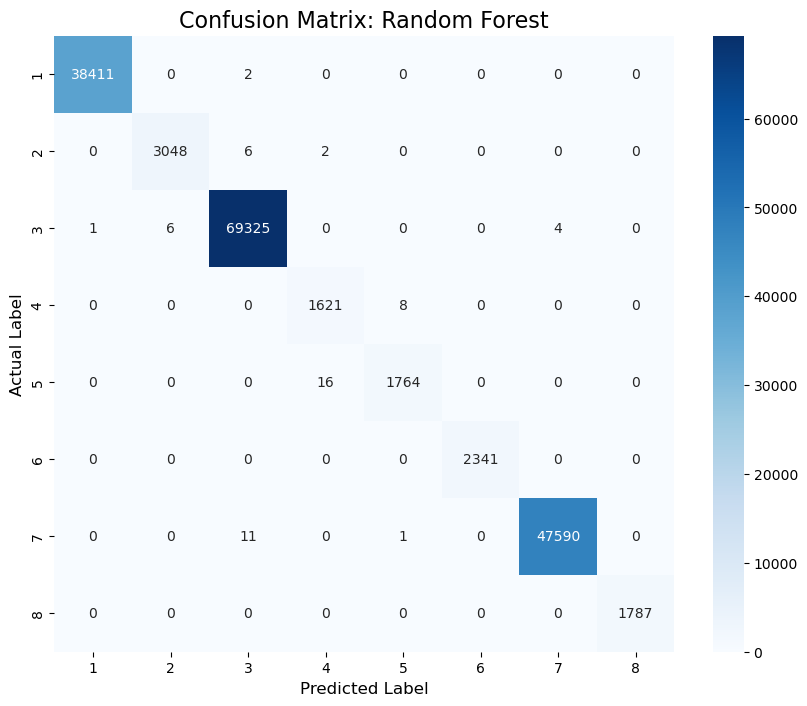


🚀 Training and Evaluating: Decision Tree
   Fitting Decision Tree...
   ✅ Training complete in 1.88 seconds.

📊 Classification Report for Decision Tree:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38413
           2       1.00      1.00      1.00      3056
           3       1.00      1.00      1.00     69336
           4       0.99      0.99      0.99      1629
           5       0.99      0.99      0.99      1780
           6       1.00      1.00      1.00      2341
           7       1.00      1.00      1.00     47602
           8       1.00      1.00      1.00      1787

    accuracy                           1.00    165944
   macro avg       1.00      1.00      1.00    165944
weighted avg       1.00      1.00      1.00    165944

   🖼️  Generating Confusion Matrix for Decision Tree...


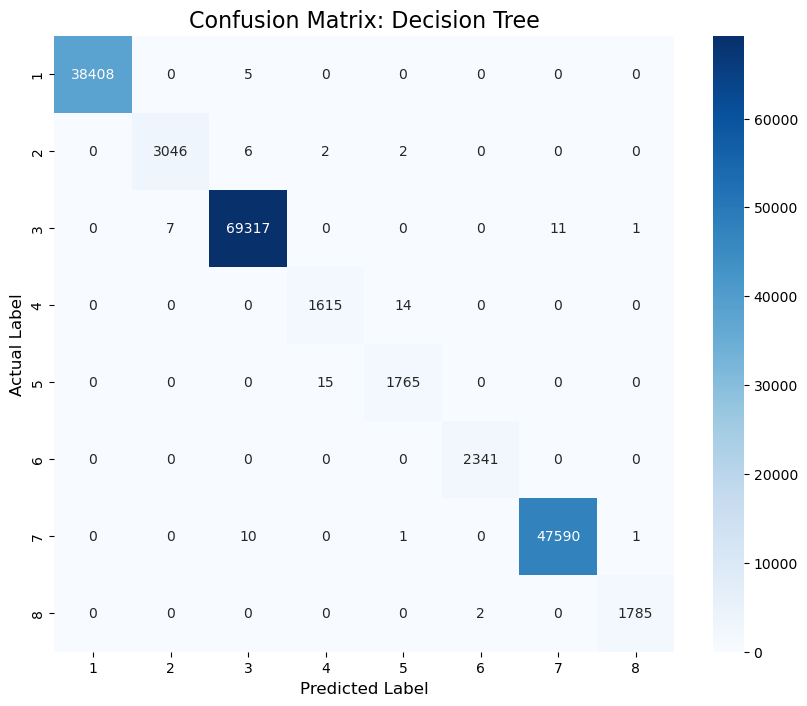


🚀 Training and Evaluating: Gaussian Naive Bayes
   Fitting Gaussian Naive Bayes...
   ✅ Training complete in 0.12 seconds.

📊 Classification Report for Gaussian Naive Bayes:
              precision    recall  f1-score   support

           1       0.97      0.46      0.62     38413
           2       0.10      0.96      0.17      3056
           3       0.99      0.26      0.41     69336
           4       0.75      0.66      0.70      1629
           5       0.68      0.61      0.64      1780
           6       0.03      0.48      0.06      2341
           7       1.00      0.99      0.99     47602
           8       0.12      1.00      0.22      1787

    accuracy                           0.54    165944
   macro avg       0.58      0.68      0.48    165944
weighted avg       0.94      0.54      0.62    165944

   🖼️  Generating Confusion Matrix for Gaussian Naive Bayes...


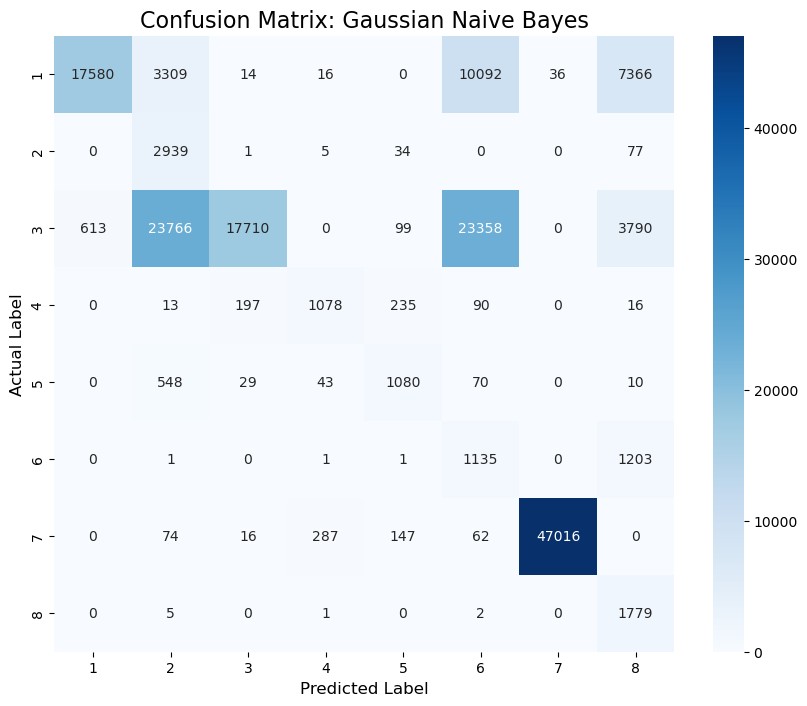



--- All model comparisons are complete. ---


In [13]:
# =====================================================================================
# ========= START: CODE BLOCK FOR TRADITIONAL MODEL COMPARISON ========================
# =====================================================================================

import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n\n\n--- Stage 3: Comparison with Traditional Machine Learning Classifiers ---")

# The data has been prepared in the previous stages. We will use the following variables:
# X_train: X_attack_train_full_df (The full training set for a fair comparison)
# y_train: y_attack_train_full_encoded_np
# X_test:  X_attack_test_df
# y_test:  y_attack_test_encoded_np

# 1. Define the dictionary of models to evaluate
models_to_compare = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    # "Support Vector Machine (SVM)": SVC(kernel='rbf', random_state=42), # WARNING: This will be extremely slow on this dataset. Uncomment if you are prepared to wait.
    "Gaussian Naive Bayes": GaussianNB()
}

# 2. Iterate through each model to train, predict, and evaluate
for model_name, model in models_to_compare.items():
    print(f"\n" + "="*60)
    print(f"🚀 Training and Evaluating: {model_name}")
    print("="*60)

    # Train the model and measure the time
    print(f"   Fitting {model_name}...")
    start_time = time.time()
    # Use the correct variable names from the main script
    model.fit(X_attack_train_full_df, y_attack_train_full_encoded_np)
    end_time = time.time()
    print(f"   ✅ Training complete in {end_time - start_time:.2f} seconds.")

    # Make predictions on the test set
    y_pred = model.predict(X_attack_test_df)

    # Print the classification report with class-wise performance
    print(f"\n📊 Classification Report for {model_name}:")
    print(classification_report(
        y_attack_test_encoded_np,
        y_pred,
        target_names=[str(cls) for cls in ATTACK_CLASS_NAMES],
        zero_division=0
    ))

    # Calculate and plot the confusion matrix
    print(f"   🖼️  Generating Confusion Matrix for {model_name}...")
    cm = confusion_matrix(y_attack_test_encoded_np, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=ATTACK_CLASS_NAMES,
                yticklabels=ATTACK_CLASS_NAMES)
    plt.title(f'Confusion Matrix: {model_name}', fontsize=16)
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.show()

print("\n\n--- All model comparisons are complete. ---")

# =====================================================================================
# ========= END: CODE BLOCK FOR TRADITIONAL MODEL COMPARISON ==========================
# =====================================================================================





--- Stage 4: Model Robustness Comparison (Noise Injection Test) ---
Comparing GNN vs. Traditional Models on training data with added noise.

--- Evaluating Random Forest ---
  Training with noise level: 0%...
  - F1-Score: 0.9997
  Training with noise level: 5%...
  - F1-Score: 0.9942
  Training with noise level: 10%...
  - F1-Score: 0.9006
  Training with noise level: 15%...
  - F1-Score: 0.8975
  Training with noise level: 20%...
  - F1-Score: 0.8950

--- Evaluating Decision Tree ---
  Training with noise level: 0%...
  - F1-Score: 0.9995
  Training with noise level: 5%...
  - F1-Score: 0.9931
  Training with noise level: 10%...
  - F1-Score: 0.9875
  Training with noise level: 15%...
  - F1-Score: 0.7385
  Training with noise level: 20%...
  - F1-Score: 0.8911

--- Evaluating GNN Bayesian Model ---
  Training with noise level: 0%...
  - F1-Score: 0.9910
  Training with noise level: 5%...
  - F1-Score: 0.9899
  Training with noise level: 10%...
  - F1-Score: 0.9882
  Training with

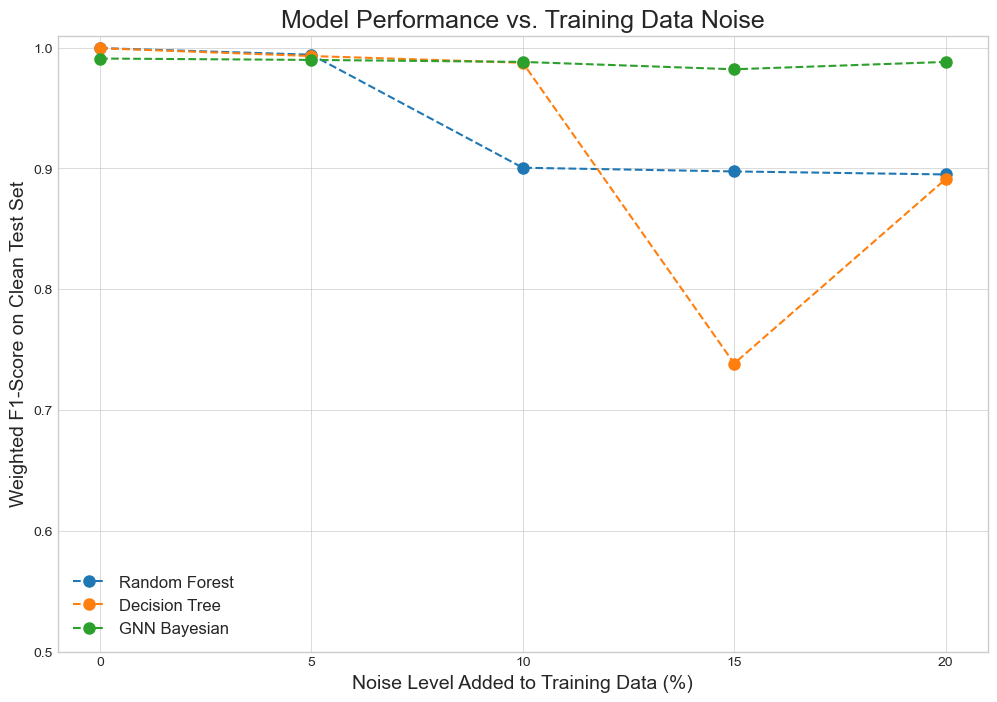


--- Robustness comparison complete. ---


In [15]:
# =====================================================================================
# ========= START: ROBUSTNESS COMPARISON SCRIPT (NOISE INJECTION) =====================
# =====================================================================================
# This script tests how model performance is affected by noise in the training data.
# A more robust, generalizable model will be less affected by noise.

import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch

print("\n\n\n--- Stage 4: Model Robustness Comparison (Noise Injection Test) ---")
print("Comparing GNN vs. Traditional Models on training data with added noise.")

# =====================================================================================
# 1. Data Preparation
# =====================================================================================
# We use the full training and test sets defined in the 'gnn_bayes_optimized' script.
# X_attack_train_full_df, y_attack_train_full_encoded_np
# X_attack_test_df, y_attack_test_encoded_np

# =====================================================================================
# 2. Define Models and Noise Levels
# =====================================================================================

# Define the levels of noise to add to the training data
# This represents the standard deviation of the noise relative to the data's scale
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20]

# Dictionary to store the F1 scores for each model at each noise level
results = {
    "Random Forest": [],
    "Decision Tree": [],
    "GNN Bayesian": []
}

# Define the traditional models
traditional_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# =====================================================================================
# 3. Train and Evaluate Traditional Models with Noise
# =====================================================================================

for model_name, model in traditional_models.items():
    print(f"\n--- Evaluating {model_name} ---")
    for noise_level in noise_levels:
        print(f"  Training with noise level: {noise_level*100:.0f}%...")
        
        # Create a noisy version of the training data
        X_train_noisy = X_attack_train_full_df.copy()
        # Add Gaussian noise scaled by the noise_level
        noise = np.random.normal(0, noise_level, X_train_noisy.shape)
        X_train_noisy += noise
        
        # Train the model on the noisy data
        model.fit(X_train_noisy, y_attack_train_full_encoded_np)
        
        # Predict and evaluate on the CLEAN test data
        y_pred = model.predict(X_attack_test_df)
        score = f1_score(y_attack_test_encoded_np, y_pred, average='weighted', zero_division=0)
        
        results[model_name].append(score)
        print(f"  - F1-Score: {score:.4f}")

# =====================================================================================
# 4. Train and Evaluate the GNN Bayesian Model with Noise
# =====================================================================================

print(f"\n--- Evaluating GNN Bayesian Model ---")
best_gnn_lr = best_lr 
OPTIMAL_EPOCHS = 250 # Use a reasonable number of epochs for this comparison

for noise_level in noise_levels:
    print(f"  Training with noise level: {noise_level*100:.0f}%...")
    
    # Create a noisy version of the training data tensor
    X_train_tensor_noisy = X_train_tensor_stage2.clone()
    noise = torch.randn_like(X_train_tensor_noisy) * noise_level
    X_train_tensor_noisy += noise
    
    # The graph structure is based on the original clean data, as we are testing
    # the model's robustness to noisy features, not a corrupted graph.
    
    # Initialize the model
    gnn_model = GNNBayesianIDS(
        in_features=X_train_tensor_stage2.shape[1],
        hidden_size=128,
        num_classes=NUM_ATTACK_CLASSES
    ).to(device)
    optimizer = torch.optim.Adam(gnn_model.parameters(), lr=best_gnn_lr)
    criterion = nn.NLLLoss(reduction='sum')

    # Train the model on the noisy data
    for epoch in range(OPTIMAL_EPOCHS):
        gnn_model.train()
        optimizer.zero_grad()
        # We use the original clean graph but the noisy features
        log_probs, kl_loss = gnn_model(X_train_tensor_noisy, train_edge_index, is_training=True)
        nll_loss = criterion(log_probs, y_train_tensor_stage2)
        total_loss = nll_loss + (kl_loss / X_train_tensor_noisy.shape[0])
        total_loss.backward()
        optimizer.step()

    # Evaluate the model on the CLEAN test data
    gnn_model.eval()
    with torch.no_grad():
        NUM_MC_SAMPLES = 10
        mc_log_probs = []
        for _ in range(NUM_MC_SAMPLES):
            log_probs_sample, _ = gnn_model(X_test_tensor_stage2, test_edge_index, is_training=False)
            mc_log_probs.append(log_probs_sample.unsqueeze(0))

        mean_log_probs = torch.logsumexp(torch.cat(mc_log_probs, dim=0), dim=0) - torch.log(torch.tensor(NUM_MC_SAMPLES, dtype=torch.float)).to(device)
        y_pred_gnn = torch.argmax(mean_log_probs, dim=1).cpu().numpy()
        
        score = f1_score(y_test_tensor_stage2.cpu().numpy(), y_pred_gnn, average='weighted', zero_division=0)
        results["GNN Bayesian"].append(score)
        print(f"  - F1-Score: {score:.4f}")

# =====================================================================================
# 5. Plot the Final Comparison
# =====================================================================================
print("\n\n--- Plotting Robustness to Noise Comparison ---")

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 8))

for model_name, scores in results.items():
    plt.plot([n * 100 for n in noise_levels], scores, marker='o', linestyle='--', label=model_name, markersize=8)

plt.title('Model Performance vs. Training Data Noise', fontsize=18)
plt.xlabel('Noise Level Added to Training Data (%)', fontsize=14)
plt.ylabel('Weighted F1-Score on Clean Test Set', fontsize=14)
plt.xticks([n * 100 for n in noise_levels])
plt.ylim(0.5, 1.01) # Adjust ylim to better see the performance drop
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.show()

print("\n--- Robustness comparison complete. ---")
# =====================================================================================
# ========= END: ROBUSTNESS COMPARISON SCRIPT =========================================
# =====================================================================================
